<div style="background: linear-gradient(135deg, #0d1b2a 0%, #1b263b 50%, #415a77 100%); border-radius: 16px; padding: 36px 40px; color: white; font-family: 'Segoe UI', sans-serif; margin-bottom: 8px;">
  <div style="font-size: 11px; letter-spacing: 3px; text-transform: uppercase; color: #a0c4ff; margin-bottom: 6px;">NLP Lab · Tuesday, 24 March 2026</div>
  <h1 style="margin: 0 0 6px 0; font-size: 2.2em; font-weight: 800; letter-spacing: -1px;">🔁 Autoregressive Language Models</h1>
  <div style="font-size: 1.1em; color: #90e0ef; margin-bottom: 4px;">RNN &nbsp;|&nbsp; LSTM &nbsp;|&nbsp; GRU — <strong style="color:#ffd166;">with Autoregressive Training</strong></div>
  <div style="display: flex; gap: 24px; flex-wrap: wrap; font-size: 0.85em; color: #caf0f8;">
    <span>👤 <strong>Suraj &amp; Debajyoti</strong></span>
    <span>📖 <a href='https://web.stanford.edu/~jurafsky/slp3/13.pdf' style='color:#a0c4ff;'>Chapter 13</a></span>
  </div>
</div>

<div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 10px; margin-top: 10px; font-family: 'Segoe UI', sans-serif;">
  <div style="background:#f0f4ff; border-left: 4px solid #4361ee; border-radius: 8px; padding: 12px 14px;">
    <div style="font-size: 0.7em; color:#4361ee; font-weight:700; letter-spacing:1px; text-transform:uppercase;">Step 1</div>
    <div style="font-weight: 600; margin-top:2px;">Setup &amp; Data</div>
    <div style="font-size: 0.8em; color: #555;">WikiText-2 corpus</div>
  </div>
  <div style="background:#f0fff4; border-left: 4px solid #2dc653; border-radius: 8px; padding: 12px 14px;">
    <div style="font-size: 0.7em; color:#2dc653; font-weight:700; letter-spacing:1px; text-transform:uppercase;">Step 2</div>
    <div style="font-weight: 600; margin-top:2px;">Build Models</div>
    <div style="font-size: 0.8em; color: #555;">RNN · LSTM · GRU</div>
  </div>
  <div style="background:#fffbf0; border-left: 4px solid #ffd166; border-radius: 8px; padding: 12px 14px;">
    <div style="font-size: 0.7em; color:#cc9900; font-weight:700; letter-spacing:1px; text-transform:uppercase;">Step 3 ★</div>
    <div style="font-weight: 600; margin-top:2px;">AR Training</div>
    <div style="font-size: 0.8em; color: #555;">Free-running loop</div>
  </div>
  <div style="background:#fdf0ff; border-left: 4px solid #9b5de5; border-radius: 8px; padding: 12px 14px;">
    <div style="font-size: 0.7em; color:#9b5de5; font-weight:700; letter-spacing:1px; text-transform:uppercase;">Step 4</div>
    <div style="font-weight: 600; margin-top:2px;">Generate Text</div>
    <div style="font-size: 0.8em; color: #555;">Autoregressive sampling</div>
  </div>
</div>

## § 1 — Setup & Imports

In [1]:
# # Install packages (run once on Colab)
# !pip install -q torch torchtext datasets sacrebleu tqdm pandas matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import time, math, random, json
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
  GPU: NVIDIA A100 80GB PCIe


## § 2 — Theory Recap **

<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 14px; margin: 16px 0; font-family: 'Segoe UI', sans-serif;">

<div style="background:#fff; border: 1px solid #e0e0e0; border-top: 4px solid #e63946; border-radius: 10px; padding: 16px;">
<strong style="color:#e63946;">🔴 Vanilla RNN</strong> <span style="font-size:0.75em; color:#888;"></span><br/>

$$h_t = \tanh(U h_{t-1} + W e_t)$$
$$\hat{y}_t = \text{softmax}(E^\top h_t)$$

<hr style="margin:8px 0; border-color:#f0f0f0;"/>
<ul style="margin:0; padding-left:16px; font-size:0.85em; line-height:1.7;">
<li>Single tanh gate</li>
<li>Weight tying: output reuses $E$ <em></em></li>
<li>⚠️ Vanishing gradients on long sequences</li>
</ul>
</div>

<div style="background:#fff; border: 1px solid #e0e0e0; border-top: 4px solid #2196f3; border-radius: 10px; padding: 16px;">
<strong style="color:#2196f3;">🔵 LSTM</strong> <span style="font-size:0.75em; color:#888;"></span><br/>

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

<hr style="margin:8px 0; border-color:#f0f0f0;"/>
<ul style="margin:0; padding-left:16px; font-size:0.85em; line-height:1.7;">
<li>3 gates: forget $f_t$, input $i_t$, output $o_t$</li>
<li>Cell state = protected memory highway</li>
<li>✅ Best long-range memory</li>
</ul>
</div>

<div style="background:#fff; border: 1px solid #e0e0e0; border-top: 4px solid #4caf50; border-radius: 10px; padding: 16px;">
<strong style="color:#4caf50;">🟢 GRU</strong> <br/>

$$h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

<br/>
<hr style="margin:8px 0; border-color:#f0f0f0;"/>
<ul style="margin:0; padding-left:16px; font-size:0.85em; line-height:1.7;">
<li>2 gates: update $z_t$, reset $r_t$</li>
<li>No separate cell state</li>
<li>⚡ ~25% fewer params than LSTM</li>
</ul>
</div>

</div>


## § 3 — Data: WikiText-2

> **WikiText-2** (Merity et al., 2017) — 2M train tokens from featured Wikipedia articles. Standard LM benchmark.

In [3]:
from datasets import load_dataset

print("Loading WikiText-2...")
raw_dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

# Dataset statistics
for split in raw_dataset:
    texts = [t for t in raw_dataset[split]['text'] if t.strip()]
    tokens = sum(len(t.split()) for t in texts)
    print(f"  {split:12s}: {len(texts):6,} articles | {tokens:8,} tokens")

print()
# Sample line
samples = [t for t in raw_dataset['train']['text'] if len(t.strip()) > 100][:2]
for s in samples:
    print(f"  Sample: {s[:130]}...")
    print()

Loading WikiText-2...
  test        :  2,891 articles |  241,211 tokens
  train       : 23,767 articles | 2,051,910 tokens
  validation  :  2,461 articles |  213,886 tokens

  Sample:  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred ...

  Sample:  The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained...



In [4]:
# ── Vocabulary Building ──────────────────────────────────────────────────────

def build_vocab(texts, min_freq=2, max_vocab=20000):
    """Word-level vocabulary with special tokens."""
    counter = Counter()
    for text in texts:
        counter.update(text.lower().split())
    vocab = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
    for word, freq in counter.most_common(max_vocab):
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)
    return vocab

train_texts = [t for t in raw_dataset['train']['text'] if t.strip()]
vocab = build_vocab(train_texts)
idx2word = {v: k for k, v in vocab.items()}
VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE:,}")
print(f"Top-10 words: {list(vocab.keys())[4:14]}")

Vocabulary size: 20,004
Top-10 words: ['the', ',', '.', 'of', 'and', 'in', 'to', 'a', '=', '"']


In [5]:
# ── Dataset & DataLoader ─────────────────────────────────────────────────────

class WikiTextDataset(Dataset):
    """
    Sliding-window sequences for language modeling.
    Each sample: (x, y) where y = x shifted right by 1.
    """
    def __init__(self, texts, vocab, seq_len=64):
        self.seq_len = seq_len
        # Tokenise & concatenate all articles with <eos> separator
        all_tokens = []
        for text in texts:
            if text.strip():
                tokens = [vocab.get(w, vocab['<unk>']) for w in text.lower().split()]
                if tokens:
                    all_tokens.extend(tokens)
                    all_tokens.append(vocab['<eos>'])
        self.tokens = torch.tensor(all_tokens, dtype=torch.long)
        self.n_seqs = (len(self.tokens) - 1) // seq_len

    def __len__(self): return self.n_seqs

    def __getitem__(self, idx):
        s = idx * self.seq_len
        return self.tokens[s:s+self.seq_len], self.tokens[s+1:s+self.seq_len+1]

SEQ_LEN, BATCH_SIZE = 64, 64

print("Building datasets...")
train_ds = WikiTextDataset([t for t in raw_dataset['train']['text'] if t.strip()], vocab, SEQ_LEN)
val_ds   = WikiTextDataset([t for t in raw_dataset['validation']['text'] if t.strip()], vocab, SEQ_LEN)
test_ds  = WikiTextDataset([t for t in raw_dataset['test']['text'] if t.strip()], vocab, SEQ_LEN)

print(f"  Train: {len(train_ds):,} sequences")
print(f"  Val:   {len(val_ds):,} sequences")
print(f"  Test:  {len(test_ds):,} sequences")

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, pin_memory=True)
print(f"\nLoaders ready. Batches — Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Building datasets...
  Train: 32,432 sequences
  Val:   3,380 sequences
  Test:  3,814 sequences

Loaders ready. Batches — Train: 507, Val: 53, Test: 60


## § 4 — Model Implementations

All three models share the same interface: `forward(x, hidden)` → `(logits, hidden)`. Key design choices applied uniformly:
- **Weight tying** — output projection reuses the embedding matrix $E$ **, cutting parameters
- **Orthogonal init** — stabilizes RNN/GRU training from the start
- **Forget-gate bias = 1** *(LSTM only)* — encourages long-range memory early in training *(Jozefowicz et al., 2015)*

In [6]:
# ── 4.1 Vanilla RNN ────────────────────────────────────

class RNNLanguageModel(nn.Module):
    """
    Elman RNN Language Model.
    hₜ = tanh(U·hₜ₋₁ + W·eₜ)
    ŷₜ = softmax(Eᵀ·hₜ)               [weight-tied output, Eq 13.14]
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.model_type = 'RNN'
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True,
                          dropout=dropout if num_layers>1 else 0, nonlinearity='tanh')
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size, bias=False)
        self.fc.weight = self.embedding.weight          # ← WEIGHT TYING
        self._init_weights()
    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for n, p in self.rnn.named_parameters():
            nn.init.orthogonal_(p) if 'weight' in n else nn.init.zeros_(p)
    def forward(self, x, hidden=None):
        out, hidden = self.rnn(self.drop(self.embedding(x)), hidden)
        return self.fc(self.drop(out)), hidden
    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

print("✅ RNNLanguageModel defined")

✅ RNNLanguageModel defined


In [7]:
# ── 4.2 LSTM ────────────────────────────────────────────────────

class LSTMLanguageModel(nn.Module):
    """
    LSTM Language Model.
    Gates: forget fₜ, input iₜ, output oₜ
    Cell: cₜ = fₜ⊙cₜ₋₁ + iₜ⊙c̃ₜ   [protected memory highway]
    Hidden: hₜ = oₜ⊙tanh(cₜ)
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.model_type = 'LSTM'
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True,
                            dropout=dropout if num_layers>1 else 0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size, bias=False)
        self.fc.weight = self.embedding.weight          # ← WEIGHT TYING
        self._init_weights()
    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for n, p in self.lstm.named_parameters():
            if 'weight_ih' in n: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in n: nn.init.orthogonal_(p)
            elif 'bias' in n:
                nn.init.zeros_(p)
                # Forget-gate bias = 1: helps long-range memory (Jozefowicz et al. 2015)
                p.data[p.size(0)//4 : p.size(0)//2].fill_(1.0)
    def forward(self, x, hidden=None):
        out, hidden = self.lstm(self.drop(self.embedding(x)), hidden)
        return self.fc(self.drop(out)), hidden
    def init_hidden(self, batch_size):
        z = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        return (z, z.clone())

print("✅ LSTMLanguageModel defined")

✅ LSTMLanguageModel defined


In [8]:
# ── 4.3 GRU (Cho et al., 2014) ───────────────────────────────────────────────

class GRULanguageModel(nn.Module):
    """
    GRU Language Model (Cho et al., 2014).
    Gates: update zₜ, reset rₜ  (no separate cell state — simpler than LSTM)
    hₜ = (1-zₜ)⊙hₜ₋₁ + zₜ⊙h̃ₜ   [interpolate old and new]
    ~25% fewer parameters than LSTM for same hidden_size.
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size, self.num_layers = hidden_size, num_layers
        self.model_type = 'GRU'
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.gru = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True,
                          dropout=dropout if num_layers>1 else 0)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size, bias=False)
        self.fc.weight = self.embedding.weight          # ← WEIGHT TYING
        self._init_weights()
    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        for n, p in self.gru.named_parameters():
            nn.init.orthogonal_(p) if 'weight' in n else nn.init.zeros_(p)
    def forward(self, x, hidden=None):
        out, hidden = self.gru(self.drop(self.embedding(x)), hidden)
        return self.fc(self.drop(out)), hidden
    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)

print("✅ GRULanguageModel defined")

✅ GRULanguageModel defined


In [9]:
# ── 4.4 Parameter Count & Model Sizes ────────────────────────────────────────

EMBED_SIZE  = 128
HIDDEN_SIZE = 128
NUM_LAYERS  = 1
DROPOUT     = 0.3

def count_params(m): 
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

rnn_model  = RNNLanguageModel( VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
lstm_model = LSTMLanguageModel(VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
gru_model  = GRULanguageModel( VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)

print(f"{'='*58}")
print(f"  {'Model':<10} {'Params':>10}  {'Recurrent core':<25} Layers")
print(f"{'='*58}")
for m, n in [(rnn_model,'RNN'), (lstm_model,'LSTM'), (gru_model,'GRU')]:
    core = {'RNN':'1 gate (tanh)','LSTM':'3 gates + cell state','GRU':'2 gates (no cell)'}[n]
    print(f"  {n:<10} {count_params(m):>10,}  {core:<25} {NUM_LAYERS}")
print(f"{'='*58}")
print(f"\n  embed_size={EMBED_SIZE}, hidden_size={HIDDEN_SIZE}, dropout={DROPOUT}")
print(f"  Note: embedding ({VOCAB_SIZE}×{EMBED_SIZE}) weight-tied to output projection.")

  Model          Params  Recurrent core            Layers
  RNN         2,593,536  1 gate (tanh)             1
  LSTM        2,692,608  3 gates + cell state      1
  GRU         2,659,584  2 gates (no cell)         1

  embed_size=128, hidden_size=128, dropout=0.3
  Note: embedding (20004×128) weight-tied to output projection.


## § 5 — Autoregressive Training ★

<div style="background:#fffbf0; border-left: 5px solid #ffd166; border-radius: 8px; padding: 14px 18px; margin: 12px 0; font-family: 'Segoe UI', sans-serif;">
<strong>Key difference from teacher forcing:</strong> at each step <em>t</em>, instead of feeding the true token <em>w<sub>t</sub></em>, we feed the model's own greedy prediction $\hat{w}_t = \arg\max \hat{y}_t$. The loss is still computed against the true next token — the model must learn to recover from its own mistakes.
</div>

**Comparison at a glance:**

| | Teacher Forcing | Autoregressive Training ★ |
|---|---|---|
| Input at step $t$ | True token $w_{t-1}$ | Model's prediction $\hat{w}_{t-1}$ |
| Training speed | Fast (single forward pass) | Slower (sequential step-by-step) |
| Exposure bias | ❌ Train/test mismatch | ✅ Matches generation exactly |
| Gradient flow | Through logits only | Through logits at each step |
| Typical PPL | Lower (easier signal) | Higher (harder — model sees its errors) |

| Detail | Implementation |
|---|---|
| Loss | `CrossEntropyLoss(ignore_index=0)` — skips `<pad>` tokens |
| Next-token selection | `argmax` of logits (greedy) — no gradient through discrete step |
| Gradient clipping | `clip_grad_norm_(..., 1.0)` — essential for RNNs |
| Truncated BPTT | Hidden state detached between batches |
| Optimizer | Adam + `ReduceLROnPlateau` (patience=1, factor=0.5) |

In [10]:
def compute_perplexity(loss):
    return math.exp(min(loss, 20))   # cap to prevent overflow

def detach_hidden(h):
    """Detach hidden state from computation graph (truncated BPTT)."""
    return tuple(x.detach() for x in h) if isinstance(h, tuple) else h.detach()


# ── ★ Autoregressive training loop ────────────────────────────────────────────
# Unlike teacher forcing (which does one batched forward pass over the full
# sequence), here we unroll the sequence step-by-step.  At each step t:
#   1. Feed the model's OWN prediction from t-1 (argmax), not the true token.
#   2. Compute cross-entropy loss against y[:, t] (the true next token).
#   3. Accumulate & backprop through all steps together.
# This eliminates "exposure bias": the train-time input distribution exactly
# matches what the model sees at generation time.

def train_epoch_ar(model, loader, optimizer, criterion, clip=1.0):
    """One epoch of autoregressive (free-running) training."""
    model.train()
    total_loss, hidden = 0.0, None

    for x, y in tqdm(loader, desc="  train (AR)", leave=False):
        x, y = x.to(device), y.to(device)   # x: (B, T),  y: (B, T)
        bs, seq_len = x.size()

        # Reset / resize hidden state between batches
        if hidden is None or (isinstance(hidden, tuple) and hidden[0].size(1) != bs) or \
           (not isinstance(hidden, tuple) and hidden.size(1) != bs):
            hidden = model.init_hidden(bs)
        hidden = detach_hidden(hidden)

        optimizer.zero_grad()

        # ── Seed the loop with the first true token ──────────────────────────
        # (using x[:, 0] as seed is standard; beyond t=0, only model output is used)
        inp = x[:, 0:1]          # (B, 1) — the seed token
        batch_loss = torch.tensor(0.0, device=device)

        for t in range(seq_len):
            logits_t, hidden = model(inp, hidden)          # logits_t: (B, 1, V)
            logits_t = logits_t.squeeze(1)                 # (B, V)

            # Loss against the true next token
            batch_loss = batch_loss + criterion(logits_t, y[:, t])

            # ★ Autoregressive: greedily pick the model's best guess as next input
            with torch.no_grad():
                next_tok = logits_t.argmax(dim=-1, keepdim=True)   # (B, 1)
            inp = next_tok

        loss = batch_loss / seq_len
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)   # ← GRADIENT CLIPPING
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    """Evaluation with teacher forcing (standard — allows fair perplexity comparison)."""
    model.eval()
    total_loss, hidden = 0, None
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            bs = x.size(0)
            if hidden is None or (isinstance(hidden, tuple) and hidden[0].size(1) != bs) or \
               (not isinstance(hidden, tuple) and hidden.size(1) != bs):
                hidden = model.init_hidden(bs)
            hidden = detach_hidden(hidden)
            logits, hidden = model(x, hidden)
            total_loss += criterion(logits.view(-1, logits.size(-1)), y.view(-1)).item()
    return total_loss / len(loader)

print("✅ Autoregressive training utilities defined")

✅ Autoregressive training utilities defined


In [11]:
def train_model(model, name, n_epochs=3, lr=3e-3):
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=1, factor=0.5)
    history = {'train_ppl': [], 'val_ppl': []}
    best_val_loss, best_state = float('inf'), None

    print(f"\n{'='*62}")
    print(f"  Training {name} [AR] | {count_params(model):,} params | {n_epochs} epochs")
    print(f"{'='*62}")

    for epoch in range(1, n_epochs+1):
        t0 = time.time()
        train_loss = train_epoch_ar(model, train_loader, optimizer, criterion)  # ← AR loop
        val_loss   = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)
        train_ppl, val_ppl = compute_perplexity(train_loss), compute_perplexity(val_loss)
        history['train_ppl'].append(train_ppl)
        history['val_ppl'].append(val_ppl)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  Epoch {epoch}/{n_epochs} | Train PPL: {train_ppl:7.1f} | Val PPL: {val_ppl:7.1f} | {time.time()-t0:.0f}s")

    model.load_state_dict(best_state)
    print(f"  ✅ Best val PPL: {compute_perplexity(best_val_loss):.1f}")
    return history

# ── Train all three models (autoregressive training) ─────────────────────────
# ⚠️  AR training is ~seq_len× slower than teacher forcing per epoch.
#    Reduce N_EPOCHS or use a smaller dataset subset if time is limited.
N_EPOCHS = 3

rnn_hist  = train_model(rnn_model,  'Vanilla RNN', N_EPOCHS)
lstm_hist = train_model(lstm_model, 'LSTM',        N_EPOCHS)
gru_hist  = train_model(gru_model,  'GRU',         N_EPOCHS)


  Training Vanilla RNN [AR] | 2,593,536 params | 3 epochs


  Epoch 1/3 | Train PPL:  1033.1 | Val PPL:   763.3 | 39s


  Epoch 2/3 | Train PPL:   928.4 | Val PPL:   753.8 | 39s


  Epoch 3/3 | Train PPL:   921.1 | Val PPL:   724.3 | 40s
  ✅ Best val PPL: 724.3

  Training LSTM [AR] | 2,692,608 params | 3 epochs


  Epoch 1/3 | Train PPL:  1016.8 | Val PPL:   752.2 | 41s


  Epoch 2/3 | Train PPL:   968.9 | Val PPL:   746.8 | 42s


  Epoch 3/3 | Train PPL:   917.2 | Val PPL:   712.4 | 41s
  ✅ Best val PPL: 712.4

  Training GRU [AR] | 2,659,584 params | 3 epochs


  Epoch 1/3 | Train PPL:  1121.9 | Val PPL:   937.3 | 42s


  Epoch 2/3 | Train PPL:   951.5 | Val PPL:   840.2 | 45s


  Epoch 3/3 | Train PPL:  1036.0 | Val PPL:  1101.8 | 43s
  ✅ Best val PPL: 840.2


## § 6 — Evaluation

> **Perplexity** = how many words the model is "confused between" at each step. **Lower = better.**

> **Note:** Evaluation always uses teacher forcing (true tokens as inputs) — this is the standard benchmark convention and makes the perplexity scores comparable across the two notebooks.

In [12]:
# ── Test Perplexity ──────────────────────────────────────────────────────────

criterion = nn.CrossEntropyLoss(ignore_index=0)
results = {}

print("\n" + "="*58)
print(f"  {'Model':<12} {'Test PPL':>10} {'Val PPL':>10} {'#Params':>11}")
print("="*58)
for model, name in [(rnn_model,'RNN'), (gru_model,'GRU'), (lstm_model,'LSTM')]:
    test_loss = evaluate(model, test_loader, criterion)
    val_loss  = evaluate(model, val_loader,  criterion)
    test_ppl, val_ppl = compute_perplexity(test_loss), compute_perplexity(val_loss)
    results[name] = {'test_ppl': test_ppl, 'val_ppl': val_ppl, 'params': count_params(model)}
    print(f"  {name:<12} {test_ppl:>10.1f} {val_ppl:>10.1f} {count_params(model):>11,}")
print("="*58)
print("  ↑ Lower perplexity = better language model")


  Model          Test PPL    Val PPL     #Params
  RNN               685.9      724.3   2,593,536
  GRU               783.8      840.2   2,659,584
  LSTM              674.5      712.4   2,692,608
  ↑ Lower perplexity = better language model


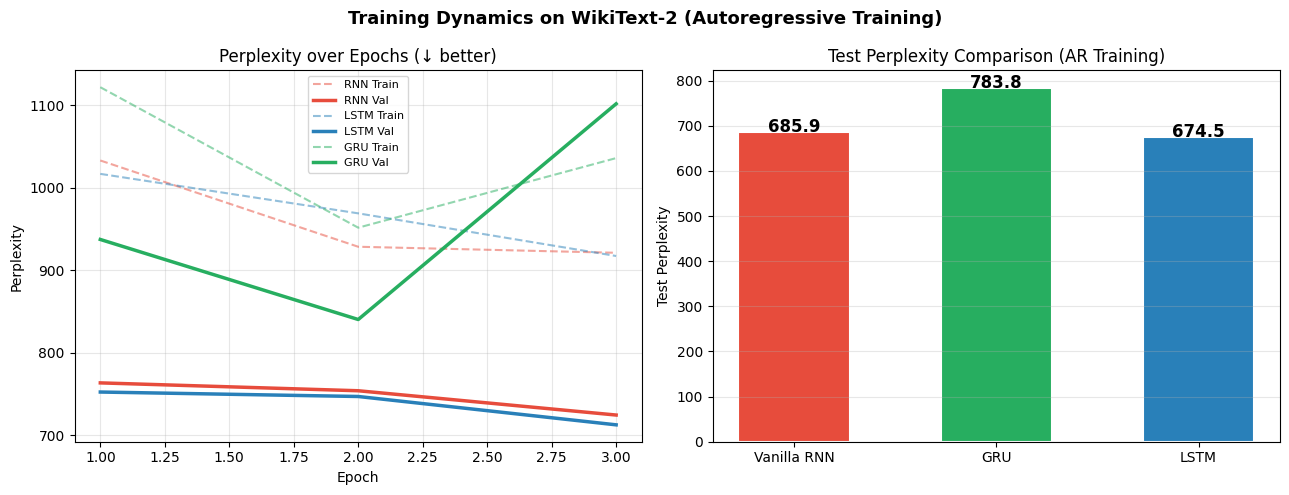

Saved: learning_curves_ar.png


In [14]:
# ── Learning Curves ──────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Training Dynamics on WikiText-2 (Autoregressive Training)', fontsize=13, fontweight='bold')

COLORS = {'RNN': '#e74c3c', 'LSTM': '#2980b9', 'GRU': '#27ae60'}
EPOCHS = list(range(1, N_EPOCHS+1))

for name, hist in [('RNN', rnn_hist), ('LSTM', lstm_hist), ('GRU', gru_hist)]:
    c = COLORS[name]
    axes[0].plot(EPOCHS, hist['train_ppl'], '--', color=c, alpha=0.5, label=f'{name} Train')
    axes[0].plot(EPOCHS, hist['val_ppl'],   '-',  color=c, lw=2.5, label=f'{name} Val')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Perplexity')
axes[0].set_title('Perplexity over Epochs (↓ better)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Bar chart of test PPL
names = ['Vanilla RNN', 'GRU', 'LSTM']
ppls  = [results['RNN']['test_ppl'], results['GRU']['test_ppl'], results['LSTM']['test_ppl']]
bars  = axes[1].bar(names, ppls, color=[COLORS['RNN'], COLORS['GRU'], COLORS['LSTM']],
                    edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, ppls):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{val:.1f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Test Perplexity'); axes[1].set_title('Test Perplexity Comparison (AR Training)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves_ar.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: learning_curves_ar.png")

## § 7 — Autoregressive Text Generation **

**Algorithm:** encode seed → loop { feed token → sample next token → repeat } until `<eos>` or max length.

**Temperature** $T$ controls sharpness: $p_i \propto \exp(\text{logit}_i / T)$

| $T$ | Effect |
|---|---|
| `< 1.0` | Conservative — peaks sharper, picks high-prob words |
| `= 1.0` | Raw model distribution |
| `> 1.0` | Creative / noisy — flatter distribution |

In [15]:
def generate(model, seed, vocab, idx2word, max_len=60, temperature=0.8, top_k=40):
    """Autoregressive generation —"""
    model.eval()
    tokens = [vocab.get(w, vocab['<unk>']) for w in seed.lower().split()] or [vocab['<sos>']]
    generated = tokens.copy()

    with torch.no_grad():
        x = torch.tensor([tokens], dtype=torch.long, device=device)
        hidden = model.init_hidden(1)
        logits, hidden = model(x, hidden)
        inp = torch.tensor([[generated[-1]]], dtype=torch.long, device=device)

        for _ in range(max_len):
            logits, hidden = model(inp, hidden)
            logits = logits[:, -1, :] / temperature
            if top_k > 0:                                # top-k nucleus filtering
                top_vals, _ = torch.topk(logits, top_k)
                logits[logits < top_vals[:, -1:]] = float('-inf')
            probs = torch.softmax(logits, dim=-1)
            nxt = torch.multinomial(probs, 1).item()
            generated.append(nxt)
            if nxt == vocab['<eos>']: break
            inp = torch.tensor([[nxt]], dtype=torch.long, device=device)

    return ' '.join(idx2word.get(t, '<unk>') for t in generated)

# ── Qualitative Comparison ────────────────────────────────────────────────────
seeds = [
    "the history of",
    "in the nineteenth century",
    "scientists have discovered",
    "the university was founded in",
]

print("\n" + "="*72)
print("  QUALITATIVE TEXT GENERATION COMPARISON (temperature=0.8, top_k=40)")
print("="*72)
for seed in seeds:
    print(f"\n📌 Seed: \"{seed}\"")
    print("-"*72)
    for m, n in [(rnn_model,'RNN '), (gru_model,'GRU '), (lstm_model,'LSTM')]:
        print(f"  [{n}] {generate(m, seed, vocab, idx2word)}")


  QUALITATIVE TEXT GENERATION COMPARISON (temperature=0.8, top_k=40)

📌 Seed: "the history of"
------------------------------------------------------------------------
  [RNN ] the history of was in of ( . @-@ , the <unk> the was @-@ in , that <eos>
  [GRU ] the history of <unk> of , of bayonets for as by , , <unk> he in 's . of and the ( , for to <unk> for " , of <unk> to that to from by the 's for was the was as the , ( of , <unk> with and @-@ the and , of to . , his which <eos>
  [LSTM] the history of by the . . " , " the to at the for of <unk> , = = with its <unk> <unk> . by = the the " the <eos>

📌 Seed: "in the nineteenth century"
------------------------------------------------------------------------
  [RNN ] in the nineteenth century was that . the , also ( a to the and by a the , its <unk> and the = , . . he of and the the a the . <unk> , , to . <eos>
  [GRU ] in the nineteenth century <unk> , , " <eos>
  [LSTM] in the nineteenth century was to , , be <eos>

📌 Seed: "scienti

In [16]:
# ── Temperature Ablation Study ────────────────────────────────────────────────

seed = "the history of science"
print(f"\n🌡️  Temperature Ablation | Model: LSTM | Seed: \"{seed}\"")
print("="*72)
for T in [0.4, 0.7, 1.0, 1.4]:
    label = {0.4:'conservative', 0.7:'balanced', 1.0:'raw model', 1.4:'creative/noisy'}[T]
    gen = generate(lstm_model, seed, vocab, idx2word, temperature=T)
    print(f"  T={T} ({label}):")
    print(f"    {gen}")
    print


🌡️  Temperature Ablation | Model: LSTM | Seed: "the history of science"
  T=0.4 (conservative):
    the history of science that the , <unk> in <unk> the of . the for a the the the the the the a of the an , and and of the <unk> . . the the to , the , the the . the , <unk> of the . . the the the , , . the . <unk> , the the the the
  T=0.7 (balanced):
    the history of science in had and <eos>
  T=1.0 (raw model):
    the history of science in , . the , <unk> <unk> and it = <unk> the and , , in a was . it of not . a the from , the the and = and . a for to a the the 's on the a " his <unk> , from at he the was had of the , = were , <unk>
  T=1.4 (creative/noisy):
    the history of science in the <unk> be a in with <unk> , the at that with of not of the be at . an ( ) was this " the ) the , = to to as , had the of <unk> which by and that . as = <unk> in with , and to . its . = was the the <unk>
